<a href="https://colab.research.google.com/github/nicolas123aguilar123-jpg/Practica-aprendizaje-no-supervisado---Sales_Records/blob/main/Proyecto2_Sarai_Alvarez_Nicolas_Aguilar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 6 — Redes neuronales artificiales (fundamentos)

**Objetivo:** construir y entrenar tu primer MLP en Keras y compararlo con Random Forest.

> Completa las celdas marcadas con `# TODO`. No borres las celdas de contexto: son tu apunte.


## 1. Concepto
## que es una red neuronal(MLP)
una red neuronal intenta imitar l funcionamiento del cerebro humano
esta formada x neuronas artificales organizadas en capas:
- capa de entreda
- capas ocultas
- salida

cada neurona recibe informacion , realiza un calculo y pasa a la sig capa




## 2. Demo (seguimiento en vivo)

Copia y ejecuta aquí el código que se muestre en la demo, adaptándolo si hace falta.


In [ ]:



import pandas as pd #trabajar con tablas de datos
import numpy as np #para trabajar con operaciones matematicas y matrices
import tensorflow as tf # para crear y entrenar redes neuronales
from tensorflow.keras import layers, models #importa 2 modulos : keras para crear capas , models :para construir el modelo completo
from sklearn.model_selection import train_test_split #divide el dataset en part entrenamiento y part prueba
from sklearn.compose import ColumnTransformer# permite aplicar dif tratamientos segun el tipo de columna
from sklearn.preprocessing import OneHotEncoder, StandardScaler # importa 2 transformaciones : standscaler = estandaliza los datos, onehotencoder= convierte text en numeros
import matplotlib.pyplot as plt# para hacer graficos

tf.random.set_seed(42)

df = pd.read_csv('dataset_s2.csv')

df['antiguedad_anios'] = df['antiguedad_anios'].fillna(df['antiguedad_anios'].median())#llena los datos vacios
mediana = df['precio_usd'].median()# crea una nueva variable k calcula la mediana del precio
df['precio_alto'] = (df['precio_usd'] > mediana).astype(int)# crea la columna objetivo para k el problema no sea de regresion sino de clasificacion binaria


num_cols = ['m2', 'habitaciones', 'antiguedad_anios']#variables numerica
cat_cols = ['zona']# variables categoricas
X = df[num_cols + cat_cols]# seleccionar las variables de entrada
y = df['precio_alto']#variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#separa el 80% entrenamiento y el 20% prueba

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),#estandarizar las variables num
        ('cat', OneHotEncoder(drop='first'), cat_cols)# transformar a numeros las variables categoricas
    ])

X_train_preprocessed = preprocessor.fit_transform(X_train)#????
X_test_preprocessed = preprocessor.transform(X_test)#???

print("filas , columnas")##OneHotEncoder convirtio varias colums a binarias y drop='first' queda representada x 2 columnas
print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)

filas , columnas
(160, 5)
(40, 5)


In [ ]:
# crear la red neuronal
#Sequential las capas estan una detras de otra

model = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],)),#define la entrada, la cant columnas = cant valores entrada
    layers.Dense(16, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),#primera capa oculta tiene 16 neuronas
    layers.Dense(8, activation='relu'),#2da capa oculta 8 neuronas
    layers.Dense(1, activation='sigmoid')# capa salida 1 neurona, xq es calsificacion binaria y la funcion sigmoid devuelve un valor entre 0 y 1
])


# optimizer='adam'  el algoritmo k ajusta los pesos de la red para reducir el error, corrige los pesos para k la red cometa menos errores
# loss='binary_crossentropy es la funcion de perdida para clasificacion binaria, mide k tan equivocadas/mala estan las predicciones
# metrics=['accuracy']    es es porcentaje de aciertos de la prediccion
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()# muestra la arquitectura

 #= relu? es una funcion de activacion , indica k tan importante escada entrada,
    # sirve para k la red aprenda relaciones complejas y no solo lineales,
    #si no usamos relu la red seria una regresion lineal enorme
 #= sigmoid  su formula produce valores entre 0 y 1,

#=cuando usar uhna determinada funcion de activacion?
#normalmente en las primeras capas se usa relu xq aprende relaciones complejas, es rapida , evita problemas de entrenamiento
# en la ultima capa depende del problema:
  # clasificaion binaria(0    1)   si o no, se usa sigmoid xq devuelve una probabbilidad entre 1 y 0
  # calsificacion multiclase : si queremos reconocer diferentes tipos de clases ejemplo animales ,
     # se usa softmax xq devuelve la probabilidad de cada clase( perro 0,80, gato 0.15, caballo 0.05 = la suma 1)
  # regresion   cuando queremos predecir, es un numero
#=si pongo relu en todas las capas??? nos dara un resultado numerico  y no sirve para una clasificacion binaria
#= si pongo sigmoid en todas las capas???  entrena mucho mas lento pero sus resultados serian malos

#CHULETA: SIRVE PARA SABER K TIPO DE FUNCION DE ACTIVACION USAR SEGUN EL TIPO DE PROBLEMA:
# problema  de clasificacion binaria= Relu en capas ocultas, y sigmoid en capa salida
# problem con varias clases: relu en capas ocultas y softmax en capa salida
# problem regresion : relu en ocultas y linear en salida


# param #  :  entradas + 1 bia x cada neurona
#capa1
# cada neurona necesita 1 peso x cada entrada  y cada neurona tiene 1 bia
# entonces tenemos 5 entradas(5 col)= 5 pesos
# entonces para la capa de 16 neuronas tenemos: 5 *16 neuronas(en cada neurona hay 5 pesos) + 16(1 bia x cada neurona)
# = 80 + 16 = 96  parametros

#capa 2
# recibe la salida de 16 neuronas(osea 16 entradas) +8 bias
#entonces como tenemos 8 neuronas = (8x16) + 8 = 136 param

#capa 3
# recibe 8 entradas mas +1 bias
#   9 *1 neurona = 9 param



# sesgo (bias)   un num extra k ayuda a mover el resultado, para k la red sea mas flexible



#en la ultima capa  caso solo tenemos una neurona  xq en nuestro caso solo existen 2 respuestas posibles  0    1 y con 1 neurona basta


#como saber cuantas neuronas aplicar???
#hiperparametro: por ejemplo primero probar
# 8 neuronas  -> 72% acuracy
# 16 neuronas  -> 80% acuracy
# 32 neuronas  -> 19% acuracy
# entonces es mejor elegir 16 meuronas  para la primera capa
# luego xq elegor 8 neuronas, xq las capas van recuciendo de informacion, xq aprende y luego se queda con la info mas importante y al final decide la clase


# como saber cuantas capas debe tener una red?
# problem sencillo 1 o 2 capas
# mediano 2 o  3 capas
# enormes   decenas o sientos de capas


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento
history = model.fit(X_train_preprocessed, y_train, epochs=10, batch_size=32, validation_split=0.2)






Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4219 - loss: 0.7177 - val_accuracy: 0.5938 - val_loss: 0.7000
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4453 - loss: 0.7118 - val_accuracy: 0.5625 - val_loss: 0.6962
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4531 - loss: 0.7063 - val_accuracy: 0.6250 - val_loss: 0.6925
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4609 - loss: 0.7011 - val_accuracy: 0.5938 - val_loss: 0.6888
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5078 - loss: 0.6961 - val_accuracy: 0.6250 - val_loss: 0.6851
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6016 - loss: 0.6912 - val_accuracy: 0.6250 - val_loss: 0.6813
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6406 - loss: 0.6866 - val_accuracy: 0.6562 - val_loss: 0.6774
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6641 - loss: 0.6820 - val_accuracy: 0.6875 - val_loss: 0.6735

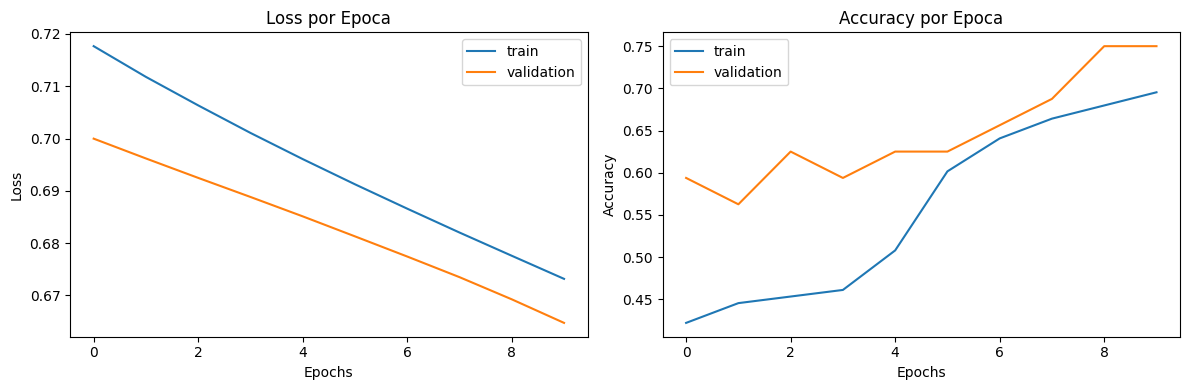

In [ ]:
# visualizar si una red neuronal realmente esta aprendiendo

plt.figure(figsize=(12, 4))#crea una nueva figura donde se dibujaran los graficos . (12 ancho , 4 alto)

#loss por epoch
plt.subplot(1, 2, 1) # primer grafico (filas, columnas, posicion)
#la informacion del entrenamiento se guarda en el history, en cada epoch
# history.history['loss'] pode la lista de todos los valores entrenados del loss
# dibuja la linea del error del entrenamiento
#label='nombre de la linea'
plt.plot(history.history['loss'], label='train')#dibujar el loss del entrenamiento
plt.plot(history.history['val_loss'], label='validation') # dibujar el error de validacion
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss por Epoca')
#grafico 1 muestra como disminuye el error  del modelo durante el entrenamiento y la validacion .
#mas bajo es loss mas aprende


#accuracy x epoch
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy por Epoca')
#grafico 2 muestra el % de aciertos del modelo en cada epoca tanto en entrenamiento y en validacion


plt.tight_layout() # para agregar espacios y evitar k los graficos se sobrepongan
plt.show()

#si las curvas del entrenamiento y validacion  estan separadas infica sobreajuste.
#los baja y e acuracy sube? es un buen entrenamiento
#ovgerfitting  si el entrenamiento mejora pero la validacion empieza a empeorar indica k el modelo esta memorizando y deja de generalizar

#train sirve para aprende
#validation vigila como va aprendiendo mientras entrena. la red no aprende con estos datos
#test son las pruebas , se guardan asta el final, el resultado ya no modifica el modelo


In [ ]:

#evaluacion final del modelo
# medimos k tan bueno es con los datos nuevos, usamos los datos k guardamos para el test
#aqui el modelo ya no aprende , ni modifica nada solo predice datos para ver k tan bien lo hace el modelo

# X_test_preprocessed  caracterirsticas variables de entrada del dataset
# y_test las respuestas correctas
# devuelde el loss y el accuracy
loss, accuracy = model.evaluate(X_test_preprocessed, y_test)
print(f'Test Loss: {loss:.4f}')# imprime el resultado con solo 4 decimales
print(f'Test Accuracy: {accuracy:.4f}')




2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6827 
Test Loss: 0.6827
Test Accuracy: 0.6250


In [ ]:

# red neuronal mas grande  para ver si con mas neuronas obtiene mejores resultados
model_grande = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(256, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_grande.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_grande.summary()


#liena en donde aprende, entrena el modelo
#X_train_preprocessed  variables de entrada,
#y_train     las respuestas correctas
#epochs  10
#batch_size  divide los registro en grupos
# validation_split divive el conjuntode entrenamiento en 80 entrenamiento y 20% validacion
history_grande = model_grande.fit(X_train_preprocessed, y_train, epochs=10, batch_size=32, validation_split=0.2)

#evalua el modelo usando el conjunto de prueba de x test y y test , no entrena ni modifica solo calcula para medir k tan buien lo hace el modelo
loss_grande, accuracy_grande = model_grande.evaluate(X_test_preprocessed, y_test)


print(f'Test Loss (Grande): {loss_grande:.4f}')
print(f'Test Accuracy (Grande): {accuracy_grande:.4f}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,353 (392.00 KB)

 Trainable params: 100,353 (392.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7266 - loss: 0.6415 - val_accuracy: 0.9062 - val_loss: 0.5214
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8672 - loss: 0.5125 - val_accuracy: 0.9375 - val_loss: 0.3782
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8906 - loss: 0.3926 - val_accuracy: 0.9375 - val_loss: 0.2525
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9141 - loss: 0.2913 - val_accuracy: 0.9688 - val_loss: 0.1839
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9141 - loss: 0.2277 - val_accuracy: 0.9375 - val_loss: 0.1631
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9141 - loss: 0.1962 - val_accuracy: 0.9062 - val_loss: 0.1535
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9219 - loss: 0.1786 - val_accuracy: 0.9062 - val_loss: 0.1351
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9453 - loss: 0.1668 - val_accuracy: 0.9062 - val_loss: 0.1219


## 3. Práctica

1. Migra el problema de clasificación de la sesión 3 a una red neuronal en Keras
2. Grafica las curvas de loss/accuracy (train vs validation) por época
3. Compara el resultado contra Random Forest
4. Agrega una capa oculta adicional y/o Dropout, y observa el efecto


In [ ]:



import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

tf.random.set_seed(42)

df = pd.read_csv('Churn_Modelling.csv')
df.head()



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:

df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:



#CreditScore =Puntuación crediticia
#Age=
#Tenure=Antigüedad
#Balance = Saldo
#NumOfProducts= Número de productos
#HasCrCard=  tarjeta de crédito
#IsActiveMember
#EstimatedSalary= sueldo estimado
#cat_cols = categorias
#Geography = geografia
#Gender= genero

#df['antiguedad_anios'] = df['antiguedad_anios'].fillna(df['antiguedad_anios'].median())#llena los datos vacios
#mediana = df['precio_usd'].median()
#df['precio_alto'] = (df['precio_usd'] > mediana).astype(int)

num_cols = ['CreditScore', 'Age', 'Tenure','Balance','NumOfProducts', 'HasCrCard','IsActiveMember','EstimatedSalary']
cat_cols = ['Geography', 'Gender']
X = df[num_cols + cat_cols]
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("filas , columnas")
print("entrenamiento",X_train_preprocessed.shape)
print("test", X_test_preprocessed.shape)


filas , columnas
entrenamiento (8000, 11)
test (2000, 11)


In [ ]:
# TODO: define el modelo Sequential (Dense + activaciones)



# 1 capas , 8-1  , 20 epoch=>       accuracy: 0.8559 - loss: 0.3485 - val_accuracy: 0.8462 - val_loss: 0.3497
# 1 capas , 16-1  , 20 epoch=>      accuracy: 0.8577 - loss: 0.3426 - val_accuracy: 0.8544 - val_loss: 0.3472

# 2 capas , 16-8-1  , 20 epoch=>    accuracy: 0.8611 - loss: 0.3344 - val_accuracy: 0.8500 - val_loss: 0.3470
                                  # accuracy: 0.8650 - loss: 0.3313 - val_accuracy: 0.8544 - val_loss: 0.3422
                                  # accuracy: 0.8614 - loss: 0.3352 - val_accuracy: 0.8550 - val_loss: 0.3470  //es la mejor opcion


 #2 capas , 16-8-1  , 50 epoch=> accuracy: 0.8680 - loss: 0.3188 - val_accuracy: 0.8544 - val_loss: 0.3461  //indicios de memorizar
 #2 capas , 16-8-1  , 30 epoch=> accuracy: : 0.8684 - loss: 0.3150 - val_accuracy: 0.8531 - val_loss: 0.3487 //indicios de memorizar


# 2 capas , 32-16-1  , 20 epoch=>   accuracy: 0.8752 - loss: 0.2981 - val_accuracy: 0.8512 - val_loss: 0.3503   // empiezan a memorizar
# 2 capas , 32-16-1  , 50 epoch=>   accuracy: 0.8727 - loss: 0.3063 - val_accuracy: 0.8494 - val_loss: 0.3454   //desde epoch 39 empiesa un poco amemorizar

#3 capas , 32-16-8-1  , 20 epoch=>  accuracy: 0.8797 - loss: 0.2942 - val_accuracy: 0.8425 - val_loss: 0.3729  //memorizar
#3 capas , 32-16-8-1  , 50 epoch=>  accuracy: 0.8763 - loss: 0.3032 - val_accuracy: 0.8487 - val_loss: 0.3618 // memoriza

# 3 capas 256-256-128-1, 20 epoch-> accuracy: 0.9055 - loss: 0.2267 - val_accuracy: 0.8406 - val_loss: 0.4275  // memoriza
# 3 capas 256-256-128-1, 50 epoch-> accuracy: 0.9859 - loss: 0.0455 - val_accuracy: 0.8138 - val_loss: 1.3377  //memoriza confirmado

model = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(16, activation='relu', input_shape=(X_train_preprocessed.shape[1])),
    layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # test Loss: 0.3376  Test Accuracy: 0.8675
# model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy']) # sgd Test Loss: 0.3732   Test Accuracy: 0.8425
# model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])# 20 epoch = Test Loss: 0.3436    Test Accuracy: 0.8595
                                                                                    # 50 epoch = Test Loss: 0.3438    Test Accuracy: 0.8565
model.summary()


#learning rate : k tan fuerte aprende el modelo en cada epoch

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento

history = model.fit(X_train_preprocessed, y_train, epochs=20, batch_size=32, validation_split=0.2)



Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7472 - loss: 0.5232 - val_accuracy: 0.8062 - val_loss: 0.4459
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8055 - loss: 0.4363 - val_accuracy: 0.8194 - val_loss: 0.4213
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8219 - loss: 0.4135 - val_accuracy: 0.8281 - val_loss: 0.4030
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8375 - loss: 0.3932 - val_accuracy: 0.8356 - val_loss: 0.3881
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8470 - loss: 0.3773 - val_accuracy: 0.8431 - val_loss: 0.3769
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8525 - loss: 0.3659 - val_accuracy: 0.8475 - val_loss: 0.3690
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8547 - loss: 0.3582 - val_accuracy: 0.8481 - val_loss: 0.3638
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8564 - loss: 0.3531 - val_accuracy: 0.

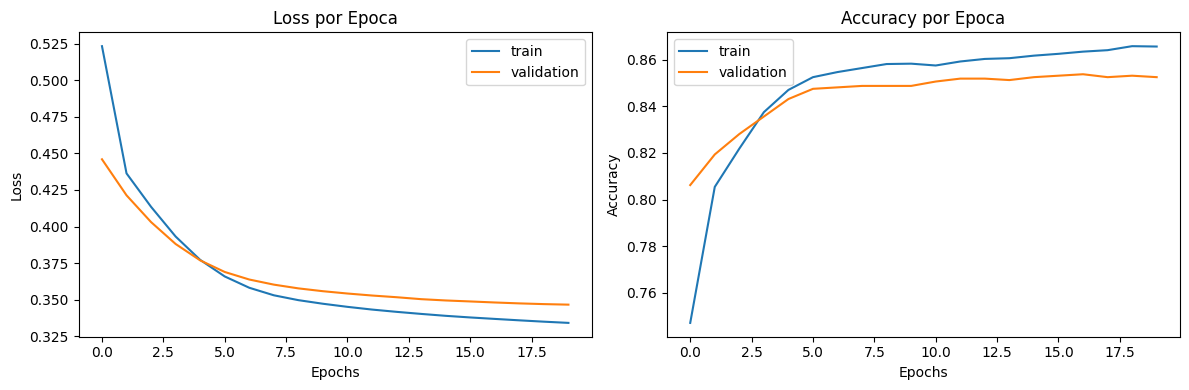

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss por Epoca')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy por Epoca')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: compila el modelo (optimizer, loss, metrics)
loss, accuracy = model.evaluate(X_test_preprocessed, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8560 - loss: 0.3459
Test Loss: 0.3459
Test Accuracy: 0.8560


In [ ]:
# red grande

model_grande = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(256, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_grande.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_grande.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,889 (398.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento

history_grande = model_grande.fit(X_train_preprocessed, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8323 - loss: 0.4010 - val_accuracy: 0.8469 - val_loss: 0.3520
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8542 - loss: 0.3518 - val_accuracy: 0.8500 - val_loss: 0.3468
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8602 - loss: 0.3410 - val_accuracy: 0.8544 - val_loss: 0.3439
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.3342 - val_accuracy: 0.8525 - val_loss: 0.3428
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8656 - loss: 0.3287 - val_accuracy: 0.8525 - val_loss: 0.3423
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8659 - loss: 0.3233 - val_accuracy: 0.8544 - val_loss: 0.3438
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8672 - loss: 0.3183 - val_accuracy: 0.8550 - val_loss: 0.3449
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8700 - loss: 0.3136 - val_accuracy: 0.

In [ ]:
#evaluacion
loss_grande, accuracy_grande = model_grande.evaluate(X_test_preprocessed, y_test)
print(f'Test Loss (Grande): {loss_grande:.4f}')
print(f'Test Accuracy (Grande): {accuracy_grande:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8575 - loss: 0.3484
Test Loss (Grande): 0.3484
Test Accuracy (Grande): 0.8575


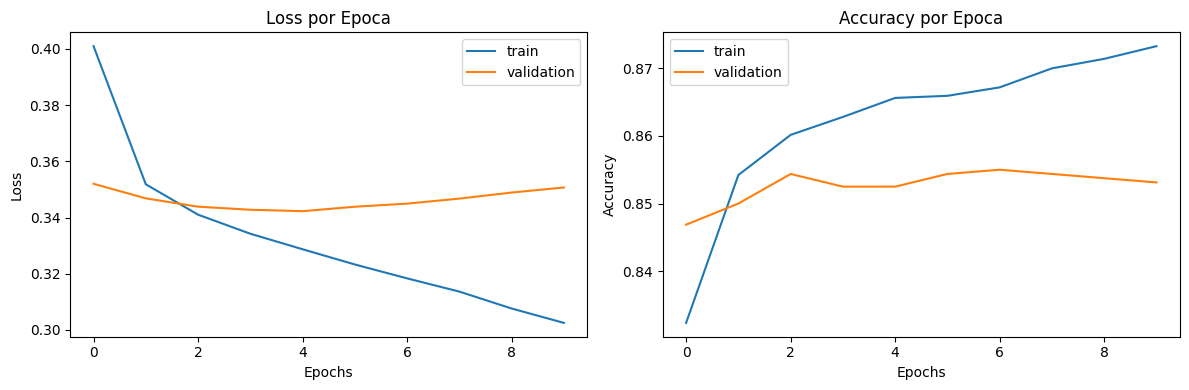

In [ ]:
# grafico red grande
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_grande.history['loss'], label='train')
plt.plot(history_grande.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss por Epoca')

plt.subplot(1, 2, 2)
plt.plot(history_grande.history['accuracy'], label='train')
plt.plot(history_grande.history['val_accuracy'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy por Epoca')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: entrena con model.fit, guardando el history


In [ ]:
# TODO: grafica loss y accuracy de train vs validation por época


In [ ]:
# TODO: compara el accuracy final contra tu Random Forest de la sesión 3


## 4. Cierre

- [ ] Completé todos los `# TODO` de esta sesión
- [ ] Ejecuté el notebook de principio a fin sin errores (`Kernel > Restart & Run All`)
- [ ] Hice commit y push a mi repo



**Conclusiones (2-3 líneas en tus palabras):**

_Escribe aquí._
